# Llama-3.2-3B LoRA Fine-tuning


In [ ]:
# Install dependencies
!pip install -q unsloth trl transformers datasets bitsandbytes peft accelerate rouge-score


In [ ]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu128
12.8
True


In [ ]:
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset
import pandas as pd
import re, gc, torch
from rouge_score import rouge_scorer
import os, json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
#  Load base model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "meta-llama/Llama-3.2-3B-Instruct",
    max_seq_length = 1024,
    dtype = None,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5000 Ada Generation. Num GPUs = 1. Max memory: 31.992 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 254/254 [00:00<00:00, 380.69it/s]
Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


In [ ]:
# Apply LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    lora_alpha = 32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

In [ ]:
# Load dataset


DATA_PATH = "/content/drive/MyDrive/your_data_folder/your_file.json"  #put your training data path here

dataset = load_dataset(
    "json",
    data_files=DATA_PATH,
    split="train"
)

print(f"Loaded {len(dataset)} examples")
print("Columns:", dataset.column_names)
print("\nSample:")
print(dataset[0])

Loaded 79901 examples
Columns: ['text']

Sample:
{'text': "<s>[INST] How to integrate SIRI in iPhone app?\n\nI am developing an iPad app. I want to integrate SIRI functionality in it. \nSo, please guide me to work on this. Actually I don't know how to  start. \nThanks,\nCp\n [/INST] Till now apple not released siri's api for third party applications.\nIf you are looking for text-to-speech, speech-to-text functionality. There are alot of external api's like:\n\nNuance - Dragon\nispeech\nOpenEars\n\nAnd a lot of other api's.\nOpenEars is a opensource offline api, and the other two are paid and online.\n </s>"}


In [ ]:
#Format dataset
def format_example(example):
    text = example["text"]
    text = text.replace("<s>", "").replace("</s>", "").strip()

    match = re.search(r"\[INST\](.*?)\[/INST\](.*)", text, re.DOTALL)
    if match:
        question = match.group(1).strip()
        answer   = match.group(2).strip()
    else:
        return {"prompt": ""}

    prompt = f"""### Instruction:
Answer the following technical troubleshooting question.

### Question:
{question}

### Answer:
{answer}"""
    return {"prompt": prompt}

In [ ]:
#ِApplying formating function
dataset = dataset.map(format_example)
dataset = dataset.remove_columns(["text"])

dataset = dataset.filter(lambda x: len(x["prompt"]) > 0)

In [ ]:
#Setting trainer parameters
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "prompt",
    packing = True,
    max_seq_length = 512,
    formatting_func = lambda x: x["prompt"] if isinstance(x["prompt"], list) else [x["prompt"]],

    args = TrainingArguments(
        output_dir = "./llama3-3b-checkpoints",
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 2,
        num_train_epochs = 2,
        learning_rate = 2e-4,
        lr_scheduler_type = "cosine",
        warmup_steps = 100,
        bf16 = True,
        fp16 = False,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        logging_steps = 50,
        save_steps = 500,
        save_total_limit = 2,
        dataloader_num_workers = 0,
        report_to = "none",
    ),
)

Unsloth: Tokenizing ["text"]: 100%|██████████| 79901/79901 [00:54<00:00, 1466.32 examples/s]


In [ ]:
#Train ─────────────────────────────────────────────────────────────
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 79,901 | Num Epochs = 2 | Total steps = 19,976
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 9,175,040 of 3,221,924,864 (0.28% trained)


Step,Training Loss
50,2.090432
100,1.962221
150,1.926238
200,1.935237
250,1.878689
300,1.876191
350,1.936593
400,1.906324
450,1.960359
500,1.894868


Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-1000\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-1500\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-2000\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-2500\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-3000\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-3500\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-4000\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-4500\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-3b-checkpoints\checkpoint-50

In [ ]:
#Save LoRA adapters
model.save_pretrained("llama3-3b-finetuned")
tokenizer.save_pretrained("llama3-3b-finetuned")
print("Saved to ./llama3-3b-finetuned")

Unsloth: Restored added_tokens_decoder metadata in llama3-3b-finetuned\tokenizer_config.json.


Saved to ./llama3-3b-finetuned


## Evaluation using Perplexity score:

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name   = "/content/drive/MyDrive/your_project_folder/finetuned_model_folder",   # put your saved model path here
    max_seq_length = 1024,
    dtype          = None,
    load_in_4bit   = True,
)
FastLanguageModel.for_inference(model)   # switch to inference mode
model.eval()


==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 3072, padding_idx=128004)
        (layers): ModuleList(
          (0): LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (

In [ ]:
#Formating function(the same as training one)
def format_example(example):
    text = example["text"]
    text = text.replace("<s>", "").replace("</s>", "").strip()

    match = re.search(r"\[INST\](.*?)\[/INST\](.*)", text, re.DOTALL)
    if match:
        question = match.group(1).strip()
        answer   = match.group(2).strip()
    else:
        return {"prompt": ""}

    prompt = f"""### Instruction:
Answer the following technical troubleshooting question.

### Question:
{question}

### Answer:
{answer}"""
    return {"prompt": prompt}

In [ ]:
#Load and format data
EVAL_PATH = "/content/drive/MyDrive/your_data_folder/Eval_file.json"    #put your Evaluation data file here
TEST_PATH = "/content/drive/MyDrive/your_data_folder/Test_file.json"    #put your Test data file here

eval_dataset = load_dataset("json", data_files=EVAL_PATH, split="train")
test_dataset = load_dataset("json", data_files=TEST_PATH, split="train")

eval_dataset = eval_dataset.map(format_example).filter(lambda x: x["prompt"] != "")
test_dataset = test_dataset.map(format_example).filter(lambda x: x["prompt"] != "")

print(f"Eval examples: {len(eval_dataset)}")
print(f"Test examples:  {len(test_dataset)}")


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/10037 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10037 [00:00<?, ? examples/s]

Map:   0%|          | 0/10062 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10062 [00:00<?, ? examples/s]

Eval examples: 10037
Test examples:  10062


In [ ]:
#perplexty function(<10 is fine)
def compute_perplexity(dataset, batch_size=4, max_samples=500):
    total_loss, total_tokens = 0.0, 0
    samples = dataset.select(range(min(max_samples, len(dataset))))

    for i in range(0, len(samples), batch_size):
        batch_texts = samples[i : i + batch_size]["prompt"]
        encodings   = tokenizer(
            batch_texts,
            return_tensors = "pt",
            padding        = True,
            truncation     = True,
            max_length     = 1024,
        ).to("cuda")

        input_ids = encodings["input_ids"]
        labels    = input_ids.clone()

        labels[labels == tokenizer.pad_token_id] = -100

        with torch.no_grad():
            outputs = model(**encodings, labels=labels)

        n_tokens     = (labels != -100).sum().item()
        total_loss   += outputs.loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss   = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity

print("Computing eval perplexity...")
eval_loss, eval_ppl = compute_perplexity(eval_dataset)
print(f"  Eval  → Loss: {eval_loss:.4f} | Perplexity: {eval_ppl:.2f}")

print("Computing test perplexity...")
test_loss, test_ppl = compute_perplexity(test_dataset)
print(f"  Test  → Loss: {test_loss:.4f} | Perplexity: {test_ppl:.2f}")

Computing eval perplexity...
  Eval  → Loss: 1.8618 | Perplexity: 6.44
Computing test perplexity...
  Test  → Loss: 1.8563 | Perplexity: 6.40


## Loss curve

In [ ]:
#Load checkpoints folder
CHECKPOINT_DIR = "/content/drive/MyDrive/Final/Cloud Project/llama3-3b-checkpoints"

checkpoints = sorted([
    d for d in os.listdir(CHECKPOINT_DIR)
    if d.startswith("checkpoint-")
], key=lambda x: int(x.split("-")[1]))

latest = os.path.join(CHECKPOINT_DIR, checkpoints[-1])
print(f"Using: {latest}")

Using: /content/drive/MyDrive/Final/Cloud Project/llama3-3b-checkpoints/checkpoint-19976


In [ ]:
#Loading the log file from trainer_state file
with open(os.path.join(latest, "trainer_state.json"), "r") as f:
    trainer_state = json.load(f)

log_history = [x for x in trainer_state["log_history"] if "loss" in x]
steps  = [x["step"] for x in log_history]
losses = [x["loss"] for x in log_history]

print(f"Loaded {len(steps)} log entries")
print(f"Steps {steps[0]} → {steps[-1]}")
print(f"Loss  {losses[0]:.4f} → {losses[-1]:.4f}")

Loaded 399 log entries
Steps 50 → 19950
Loss  2.0904 → 1.7591


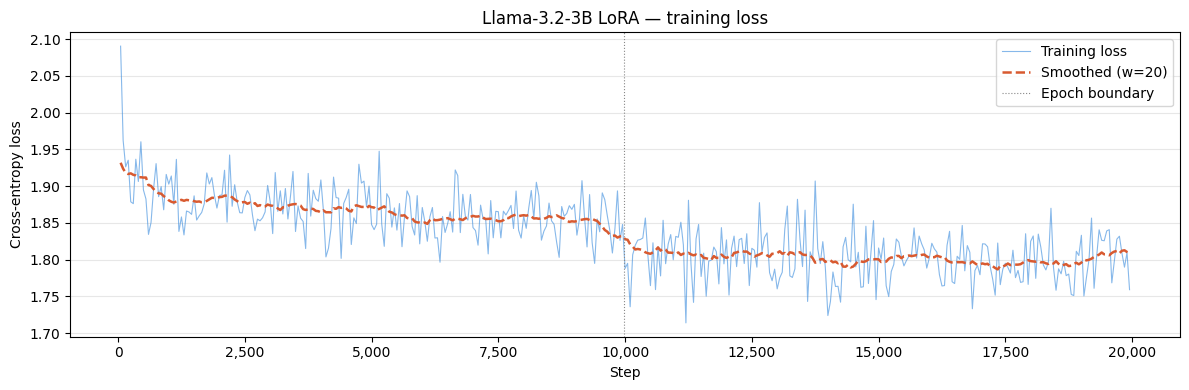

In [ ]:
#Training Loss curve
def smooth(values, window=20):
    result = []
    for i, v in enumerate(values):
        lo = max(0, i - window // 2)
        hi = min(len(values), i + window // 2 + 1)
        result.append(sum(values[lo:hi]) / (hi - lo))
    return result

smoothed = smooth(losses)
epoch_boundary = max(steps) // 2

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, losses,   color="#378ADD", linewidth=0.8, alpha=0.6, label="Training loss")
ax.plot(steps, smoothed, color="#D85A30", linewidth=1.8, linestyle="--", label="Smoothed (w=20)")
ax.axvline(epoch_boundary, color="#888", linewidth=0.8, linestyle=":", label="Epoch boundary")
ax.set_xlabel("Step"); ax.set_ylabel("Cross-entropy loss")
ax.set_title("Llama-3.2-3B LoRA — training loss")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()